# Interest Rates, Present Value and Bonds

This notebook implements the main formulas from Module 2.

The goal is to understand:

- future value
- present value
- discounting
- effective annual rates
- loan payments
- bond pricing
- price-yield relationship
- forward rates

These concepts are important because option pricing will later use the same no-arbitrage and discounting logic.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Future Value

Future value tells us how much money invested today will be worth in the future.

With discrete compounding:

FV = PV × (1 + r/n)^m

where:

- PV = present value
- r = annual nominal interest rate
- n = number of compounding periods per year
- m = total number of compounding periods

In [3]:
def future_value_discrete(PV, r, n, m):
    return PV * (1 + r/n)**m

PV = 1000
r = 0.08
n = 4
m = 4

future_value_discrete(PV, r, n, m)

1082.43216

## Interpretation

If we invest 1000 at an 8% nominal annual rate compounded quarterly, after one year we get approximately 1082.43.

This means the effective return is slightly higher than 8% because interest is compounded during the year.

# 2. Present Value

Present value reverses the future value calculation.

It answers:

How much is a future payment worth today?

With discrete compounding:

PV = FV / (1 + r/n)^m

In [4]:
def present_value_discrete(FV, r, n, m):
    return FV / (1 + r/n)**m

In [5]:
FV = 1082.43
r = 0.08
n = 4
m = 4

present_value_discrete(FV, r, n, m)

999.9980044938799

## Interpretation

Present value discounts future money back to today.

A future amount is worth less today because money today can earn interest.

# 3. Continuous Compounding

Continuous compounding assumes that interest is compounded infinitely often.

Future value:

FV = PV × e^(rT)

Present value:

PV = FV × e^(-rT)

This convention is very common in quantitative finance because it simplifies formulas.

In [6]:
def future_value_continuous(PV, r, T):
    return PV * np.exp(r * T)

def present_value_continuous(FV, r, T):
    return FV * np.exp(-r * T)

In [7]:
PV = 1000
r = 0.08
T = 1


FV = future_value_continuous(PV, r, T)
print(FV)
print(present_value_continuous(FV, r, T))

1083.2870676749587
1000.0000000000001


## Interpretation

At the same nominal rate, continuous compounding gives a slightly higher future value than quarterly compounding.

This happens because interest is added more frequently.

# 4. Experiment: Compounding Frequency

We compare how the same nominal interest rate produces different future values depending on the compounding frequency.

The question is:

How much does compounding frequency matter?

In [8]:
PV = 1000
r = 0.08
T = 1

frequencies = [1, 2, 4, 12, 52, 365]

future_values = [
    future_value_discrete(PV, r, n, n*T)
    for n in frequencies
]

continuous_value = future_value_continuous(PV, r, T)

for n, fv in zip(frequencies, future_values):
    print(f"Compounded {n} times per year: {fv:.2f}")

print(f"Continuous compounding: {continuous_value:.2f}")

Compounded 1 times per year: 1080.00
Compounded 2 times per year: 1081.60
Compounded 4 times per year: 1082.43
Compounded 12 times per year: 1083.00
Compounded 52 times per year: 1083.22
Compounded 365 times per year: 1083.28
Continuous compounding: 1083.29


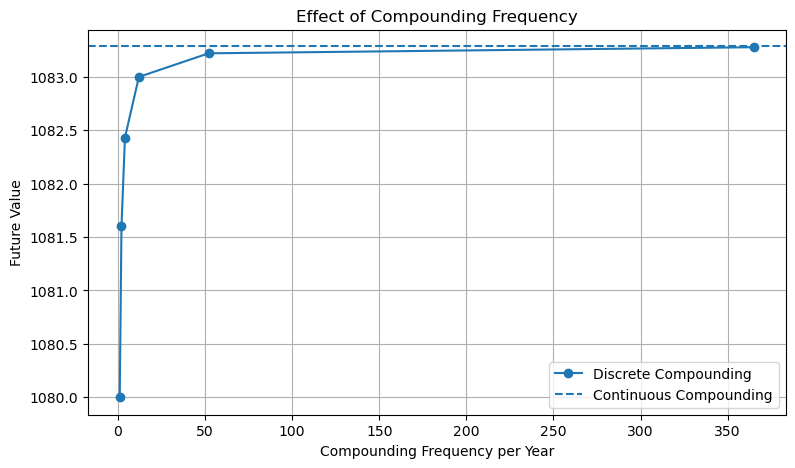

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(frequencies, future_values, marker="o", label="Discrete Compounding")
plt.axhline(continuous_value, linestyle="--", label="Continuous Compounding")
plt.title("Effect of Compounding Frequency")
plt.xlabel("Compounding Frequency per Year")
plt.ylabel("Future Value")
plt.legend()
plt.grid(True)
plt.show()

## Interpretation

As compounding becomes more frequent, future value increases.

However, it approaches a limit.

That limit is continuous compounding:

FV = PV × e^(rT)

# 5. Experiment: Bond Price vs Yield

Bond prices and yields move in opposite directions.

We will price the same bond under different yield levels and observe how the bond price changes.

In [10]:
def bond_price(face_value, coupon_rate, yield_rate, payments_per_year, years):
    total_periods = payments_per_year * years
    coupon = face_value * coupon_rate / payments_per_year
    
    coupon_pv = sum(
        coupon / (1 + yield_rate / payments_per_year) ** k
        for k in range(1, total_periods + 1)
    )
    
    face_value_pv = face_value / (1 + yield_rate / payments_per_year) ** total_periods
    
    return coupon_pv + face_value_pv

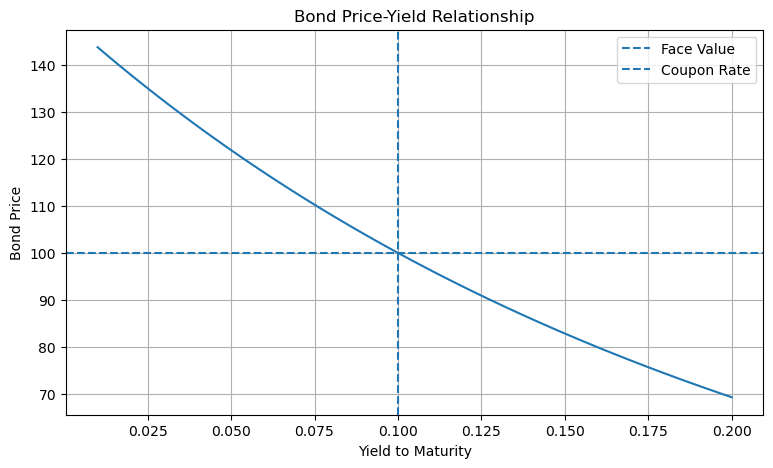

In [11]:
face_value = 100
coupon_rate = 0.10
payments_per_year = 2
years = 5

yields = np.linspace(0.01, 0.20, 100)

prices = [
    bond_price(face_value, coupon_rate, y, payments_per_year, years)
    for y in yields
]

plt.figure(figsize=(9, 5))
plt.plot(yields, prices)
plt.axhline(face_value, linestyle="--", label="Face Value")
plt.axvline(coupon_rate, linestyle="--", label="Coupon Rate")
plt.title("Bond Price-Yield Relationship")
plt.xlabel("Yield to Maturity")
plt.ylabel("Bond Price")
plt.legend()
plt.grid(True)
plt.show()

## Interpretation

When yield increases, bond price decreases.

When yield decreases, bond price increases.

If:

coupon rate = yield

then:

bond price = face value

The bond trades at par.

# 6. Experiment: Different Coupon Rates

We now compare bonds with the same maturity but different coupon rates.

Higher coupon bonds should have higher prices, because they pay larger cash flows.

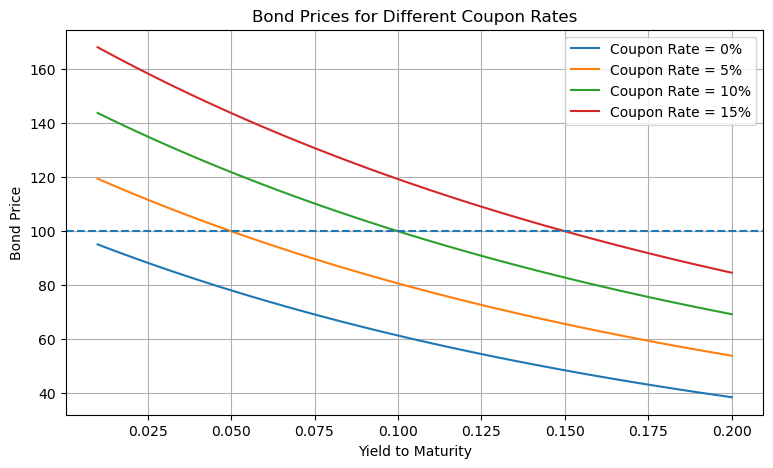

In [12]:
coupon_rates = [0.00, 0.05, 0.10, 0.15]

plt.figure(figsize=(9, 5))

for c in coupon_rates:
    prices = [
        bond_price(face_value, c, y, payments_per_year, years)
        for y in yields
    ]
    plt.plot(yields, prices, label=f"Coupon Rate = {c:.0%}")

plt.axhline(face_value, linestyle="--")
plt.title("Bond Prices for Different Coupon Rates")
plt.xlabel("Yield to Maturity")
plt.ylabel("Bond Price")
plt.legend()
plt.grid(True)
plt.show()

## Interpretation

Higher coupon bonds have higher prices because they deliver larger intermediate payments.

The zero-coupon bond has the lowest price because it only pays at maturity.

# 7. Experiment: Forward Rates

A forward rate is the interest rate implied today for a future period.

It is derived from spot rates.

The key idea is that investing directly for two years should be equivalent to investing for one year and then reinvesting for the second year at the forward rate.

In [13]:
def forward_rate(r_i, r_j, i, j, n=1):
    return n * (((1 + r_j / n) ** j / (1 + r_i / n) ** i) ** (1 / (j - i)) - 1)

In [14]:
r1 = 0.052632
r2 = 0.059998

f_1_2 = forward_rate(r1, r2, 1, 2)

print(f"1-year spot rate: {r1:.4%}")
print(f"2-year spot rate: {r2:.4%}")
print(f"Forward rate from year 1 to year 2: {f_1_2:.4%}")

1-year spot rate: 5.2632%
2-year spot rate: 5.9998%
Forward rate from year 1 to year 2: 6.7416%


## Interpretation

The forward rate is not necessarily a forecast.

It is the rate implied by today's spot rates.

A future spot rate may be higher or lower than today's forward rate.